In [53]:
import numpy as np 
import matplotlib.pyplot as plt 
from tqdm import tqdm 
import math 
import scipy
import pandas as pd

# Plot parameters 
plt.rcParams.update({
    "font.family": "serif",
    'text.latex.preamble': r'\\usepackage{amsmath}',
    'mathtext.fontset': 'cm',
})

# Load the .mat file
mat = scipy.io.loadmat('data/samples.mat')

# Print the keys 
print(mat.keys())

# Get the inputs 
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
scaler, features = StandardScaler(), PolynomialFeatures(degree=3) 
X1 = features.fit_transform(scaler.fit_transform(mat['A'][:,1:]))
X2 = features.transform(scaler.transform(mat['B'][:,1:]))
scaler, features = StandardScaler(), PolynomialFeatures(degree=2) 
X_pilot = features.fit_transform(scaler.fit_transform(mat['A']))
X_pilot = X_pilot - X_pilot.mean(axis=0)

# Get the outputs (scaling them for niceness)
y1_pilot = mat['yA'][:,0]/ 1000
ylo = mat['yB'][:,0] / 1000

# Interpolating low-fidelity at high-fidelity inputs 
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
model = Ridge(alpha=1e-9)
model.fit(X2, ylo)
yhat = model.predict(X2)
print("Quick Ridge Regression MSE: %.4e" % mean_squared_error(ylo, yhat))
y2_pilot = model.predict(X1).ravel()
print(np.corrcoef(y1_pilot.ravel(), y2_pilot.ravel()))

dict_keys(['__header__', '__version__', '__globals__', 'A', 'B', 'C', 'n', 'p', 'w', 'yA', 'yB', 'yC'])
Quick Ridge Regression MSE: 9.9655e-03
[[1.         0.93245784]
 [0.93245784 1.        ]]


In [ ]:
# Defining rcond
rcond, d = 1e-10, X_pilot.shape[1]

# Computing means 
y1_mean = np.mean(y1_pilot)
y2_mean = np.mean(y2_pilot)

# Creating the variable w = x*y(x)
xy1_pilot = X_pilot.T * (y1_pilot - y1_mean).reshape(1,-1)
xy2_pilot = X_pilot.T * (y2_pilot - y2_mean).reshape(1,-1)

# Computing the moments 
Sigma_xx = np.cov(X_pilot.T) + 1e-2 * np.eye(d)
Sigma_xy = np.cov(np.hstack((X_pilot, y1_pilot.reshape(-1,1))).T)[-1,:-1].T 
Sigma_xy1 = np.cov(xy1_pilot) # note these are variances of the product x*y_1(x), not the covariance between x and y1 
Sigma_xy2 = np.cov(xy2_pilot)
Sigma_xy12 = np.cov(np.vstack((xy1_pilot, xy2_pilot)))[:d, d:]
var_y1 = np.var(y1_pilot)
var_y2 = np.var(y2_pilot)
U, S, _ = np.linalg.svd(Sigma_xx) 
S = S[S / S[0] > rcond] # Truncating small singular values 
U = U[:,:S.shape[0]] # Truncating singular vectors 
Sigma_xx_inv = U @ np.diag(S**(-1)) @ U.T 
Sigma_xx_half_inv = U @ np.diag(S**(-0.5)) @ U.T 
n_pilot = X_pilot.shape[0]

# Defining budget and cost parameters
B = 100
c1, c2 = 10, 0.1

In [67]:
# Verifying MSE approximation with 100% high-fidelity samples
n_1 = int(B / c1)
print("Using %d hf samples" % n_1)

# Setting number of trials 
n_trials = 10000
# Creating vector of Squared errors 
squared_errors = np.zeros(n_trials)
hf_preds = np.zeros((n_pilot, n_trials))

for i in tqdm(range(n_trials)):
    # Setting random seed
    # np.random.seed(i) 
    # Taking a random sample 
    inds = np.random.choice(n_pilot, size=n_1, replace=False)
    X1 = np.copy(X_pilot[inds])
    y1 = y1_pilot[inds]
    # Performing LSR with these inputs 
    mc_cov_xy = X1.T @ (y1 - y1_mean) / n_1
    # Solving for weights 
    w = Sigma_xx_inv @ mc_cov_xy
    # Making predictions 
    yhat = X_pilot @ w + y1_mean
    hf_preds[:,i] = yhat.ravel()
    # Storing the MSE 
    squared_errors[i] = np.mean((yhat - y1_pilot)**2)
    
# Printing final squared error
print(np.mean(squared_errors))
# Computing the theoretical mse 
mc_term = np.trace(Sigma_xx_inv @ Sigma_xy1) / n_1 
irreducible_term = var_y1 - Sigma_xy.T @ Sigma_xx_inv @ Sigma_xy
print(mc_term + irreducible_term)

Using 10 hf samples


100%|██████████| 10000/10000 [01:05<00:00, 152.62it/s]

0.17903696214605067
0.17755268985375744


In [68]:
a = np.trace(Sigma_xx_inv @ Sigma_xy1) 
b = np.trace(Sigma_xx_inv @ Sigma_xy12 @ np.linalg.lstsq(Sigma_xy2, Sigma_xy12.T, rcond=rcond)[0])
n_1 = B * (c1 * (a-b) - np.sqrt(b * c1 * c2 * (a-b))) / (c1 * (c1 *(a-b) - b*c2))
n_2 = B * (-a * c1 * c2 + (c1 + c2) * np.sqrt(b * c1 * c2 *(a-b))) / (c1*c2*(a*c1 - b*(c1+c2)))
print("Using %d hf and %d lf samples" % (int(n_1), int(n_2)))
print("Budget check: %d = " % B, n_1 * c1 + (n_1 + n_2) * c2)

Using 7 hf and 229 lf samples
Budget check: 100 =  100.0


In [69]:
n_1, n_2 = int(n_1), int(n_2)
# Setting number of trials 
n_trials = 10000
# Creating vector of Squared errors 
squared_errors = np.zeros(n_trials)
mf_preds = np.zeros((n_pilot, n_trials))

for i in tqdm(range(n_trials)):
    # Setting random seed
    # np.random.seed(i) 
    # Taking a random sample 
    hf_inds = np.random.choice(n_pilot, size=n_1, replace=False)
    X1 = np.copy(X_pilot[hf_inds])
    y1_1 = y1_pilot[hf_inds]
    y2_1 = y2_pilot[hf_inds]
    lf_inds = np.random.choice(n_pilot, size=n_2, replace=False)
    X2 = np.copy(X_pilot[lf_inds])
    y2_2 = y2_pilot[lf_inds]
    # Computing optimal CV coefficient 
    A2 = n_2 / (n_1 + n_2) * Sigma_xx_half_inv @ Sigma_xy12 @ np.linalg.pinv(Sigma_xy2)
    # Computing estimate for q 
    q2_2 = A2 @ (X2.T @ (y2_2 - y2_mean)) / n_2 
    q2_1 = A2 @ (X1.T @ (y2_1 - y2_mean)) / n_1 
    q1_1 = Sigma_xx_half_inv @ (X1.T @ (y1_1 - y1_mean)) / n_1 
    q_hat = q2_2 + q1_1 - q2_1 
    # Solving for weights 
    w = Sigma_xx_half_inv @ q_hat 
    # Making predictions 
    yhat = X_pilot @ w + y1_mean 
    mf_preds[:,i] = yhat
    # Storing the MSE 
    squared_errors[i] = np.mean((yhat - y1_pilot)**2)
    
# Printing final squared error
print(np.mean(squared_errors))
mc_term = np.trace(Sigma_xx_inv @ (Sigma_xy1 - n_2 / (n_1 + n_2) * Sigma_xy12 @ np.linalg.lstsq(Sigma_xy2, Sigma_xy12.T,rcond=rcond)[0]) )/ n_1
print(mc_term + irreducible_term)

100%|██████████| 10000/10000 [02:02<00:00, 81.76it/s]

0.030598545240844897
0.03073420569480548


In [70]:
inds = np.argsort(y1_pilot)
hf_mean, hf_two_sigma = hf_preds.mean(axis=1), 2*hf_preds.std(axis=1)
mf_mean, mf_two_sigma = mf_preds.mean(axis=1), 2*mf_preds.std(axis=1)

Text(0, 0.5, 'Model-Predicted Output')

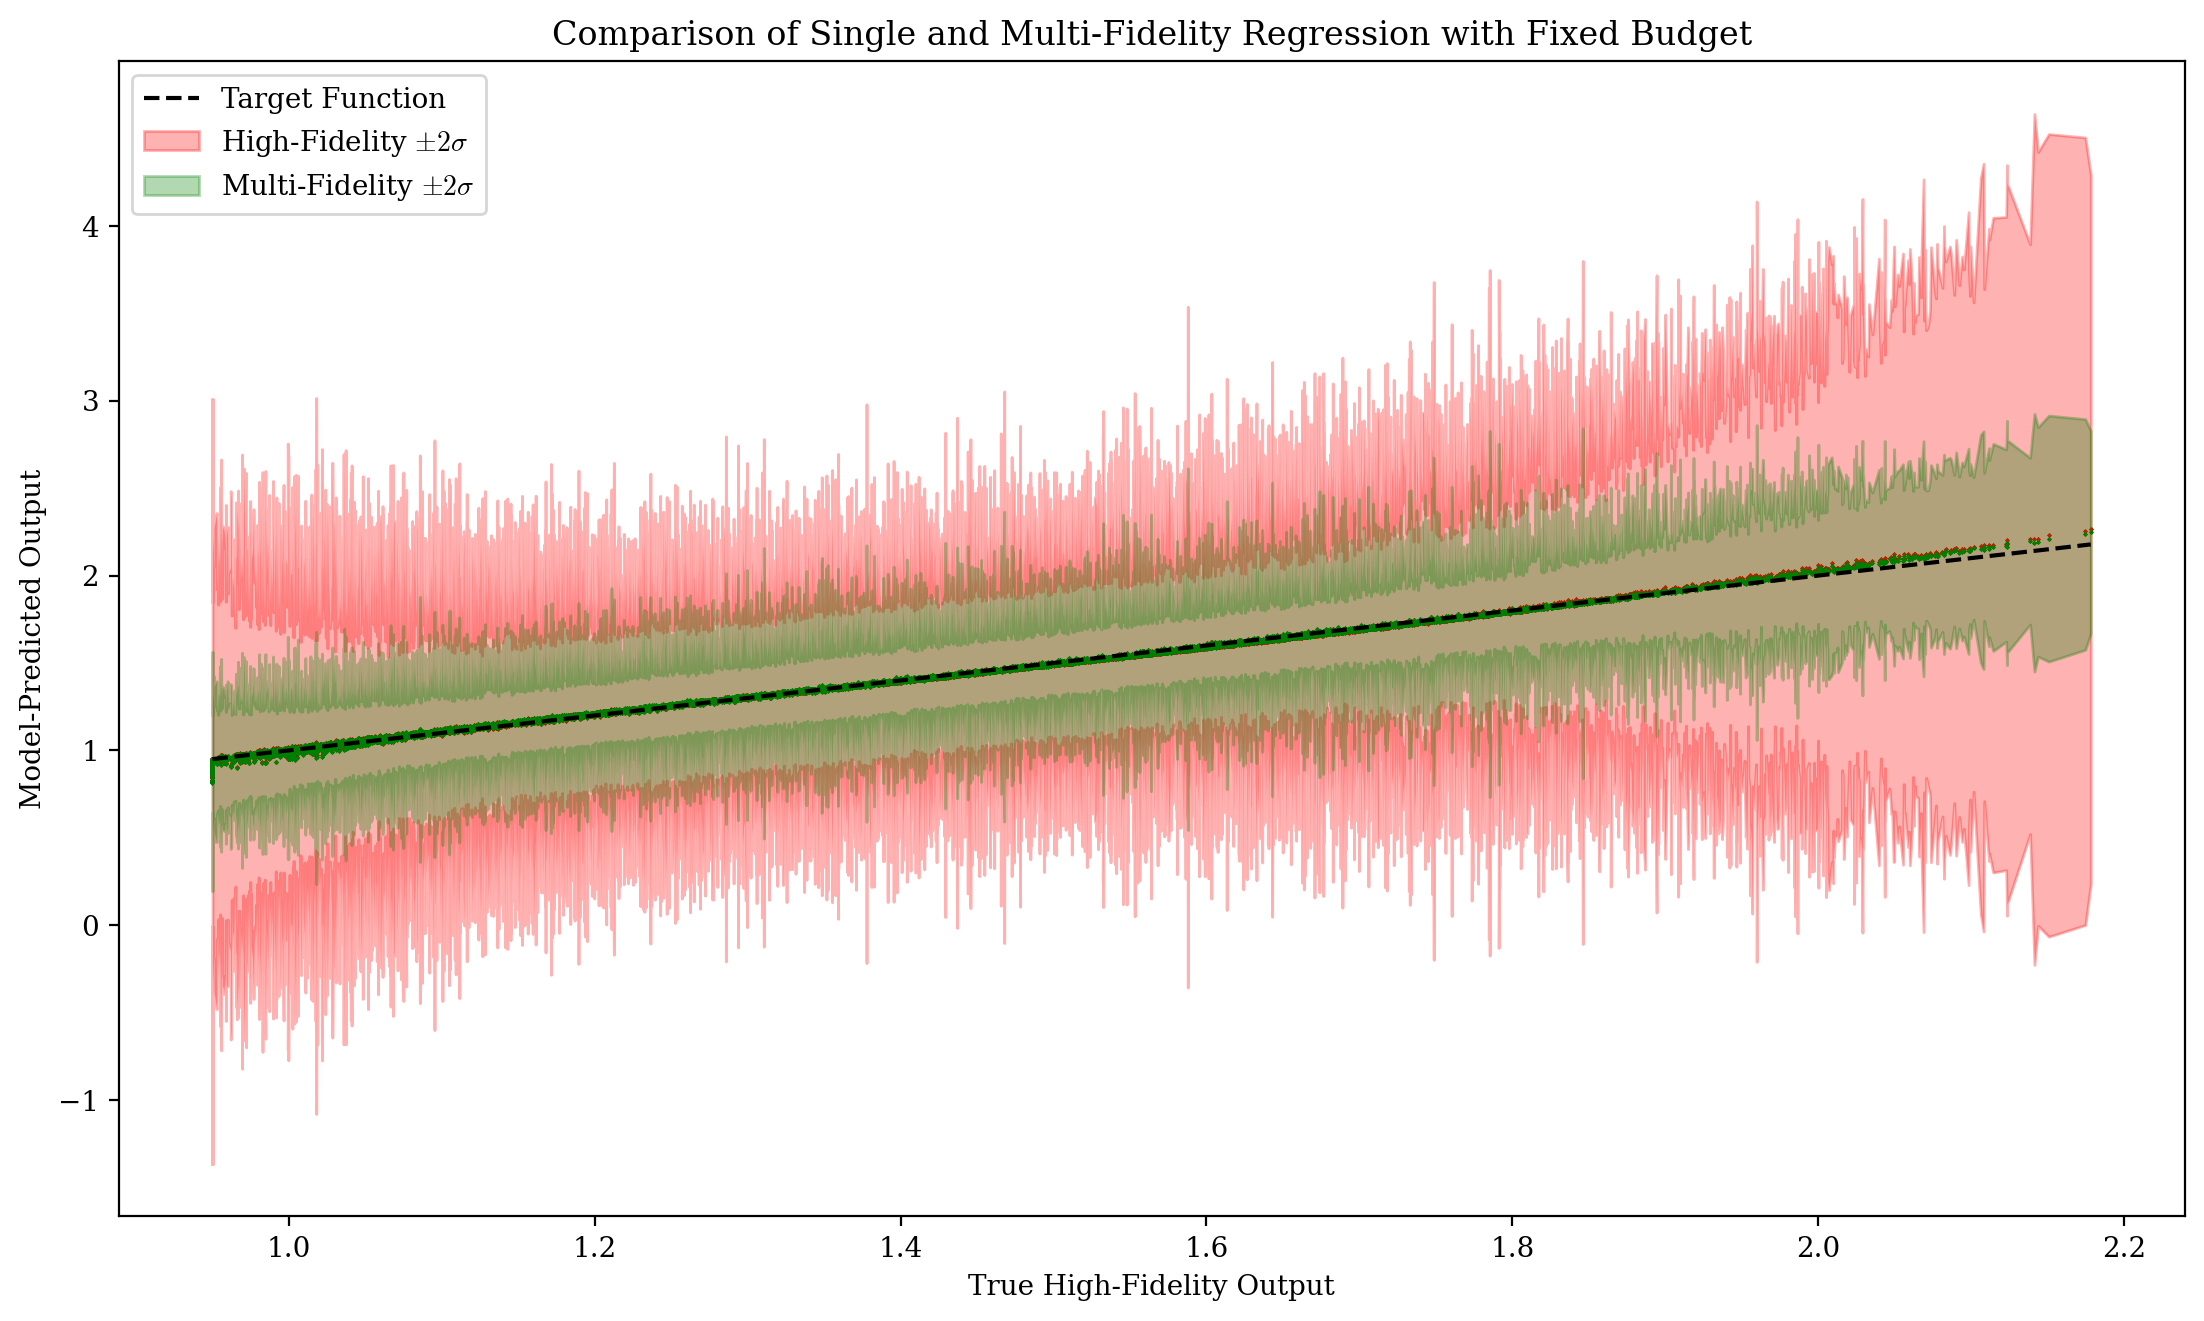

In [71]:

plt.figure(figsize=(13.33,7.5), dpi = 200)
plt.plot(y1_pilot[inds], y1_pilot[inds], label = "Target Function", linestyle = 'dashed', color = 'black')
plt.fill_between(y1_pilot[inds], hf_mean[inds] - hf_two_sigma[inds], hf_mean[inds]+ hf_two_sigma[inds], color = 'red', alpha = 0.3, label = "High-Fidelity $\\pm 2 \\sigma$")
plt.scatter(y1_pilot[inds], hf_mean[inds] , color = 'red', s = 0.05)

plt.fill_between(y1_pilot[inds], mf_mean[inds] - mf_two_sigma[inds], mf_mean[inds]+ mf_two_sigma[inds], color = 'green', alpha = 0.3, label = "Multi-Fidelity $\\pm 2 \\sigma$")
plt.scatter(y1_pilot[inds], mf_mean[inds] , color = 'green', s = 0.05)

plt.legend()
plt.title("Comparison of Single and Multi-Fidelity Regression with Fixed Budget")
plt.xlabel("True High-Fidelity Output")
plt.ylabel("Model-Predicted Output")

In [73]:
Bs = [25, 50, 100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600]
mf_means = []
mf_two_sigmas = []
hf_means = []
hf_two_sigmas = []


np.random.seed(42)
for B in tqdm(Bs): 
    a = np.trace(Sigma_xx_inv @ Sigma_xy1) 
    b = np.trace(Sigma_xx_inv @ Sigma_xy12 @ np.linalg.lstsq(Sigma_xy2, Sigma_xy12.T, rcond=rcond)[0])
    n_1 = B * (c1 * (a-b) - np.sqrt(b * c1 * c2 * (a-b))) / (c1 * (c1 *(a-b) - b*c2))
    n_2 = B * (-a * c1 * c2 + (c1 + c2) * np.sqrt(b * c1 * c2 *(a-b))) / (c1*c2*(a*c1 - b*(c1+c2)))
    print("Using %d hf and %d lf samples" % (int(n_1), int(n_2)))
    print("Budget check: %d = " % B, n_1 * c1 + (n_1 + n_2) * c2)

    n_1, n_2 = int(n_1), int(n_2)
    # Setting the minimum condition number
    rcond = 1e-13
    # Setting number of trials 
    n_trials = 1000
    # Creating vector of Squared errors 
    squared_errors = np.zeros(n_trials)
    mf_preds = np.zeros((n_pilot, n_trials))

    for i in range(n_trials):
        # Setting random seed
        # np.random.seed(i) 
        # Taking a random sample 
        hf_inds = np.random.choice(n_pilot, size=n_1, replace=False)
        X1 = np.copy(X_pilot[hf_inds])
        y1_1 = y1_pilot[hf_inds]
        y2_1 = y2_pilot[hf_inds]
        lf_inds = np.random.choice(n_pilot, size=n_2, replace=False)
        X2 = np.copy(X_pilot[lf_inds])
        y2_2 = y2_pilot[lf_inds]
        # Computing optimal CV coefficient 
        A2 = n_2 / (n_1 + n_2) * Sigma_xx_half_inv @ Sigma_xy12 @ np.linalg.pinv(Sigma_xy2)
        # Computing estimate for q 
        q2_2 = A2 @ (X2.T @ (y2_2 - y2_mean)) / n_2 
        q2_1 = A2 @ (X1.T @ (y2_1 - y2_mean)) / n_1 
        q1_1 = Sigma_xx_half_inv @ (X1.T @ (y1_1 - y1_mean)) / n_1 
        q_hat = q2_2 + q1_1 - q2_1 
        # Solving for weights 
        w = Sigma_xx_half_inv @ q_hat 
        # Making predictions 
        yhat = X_pilot @ w + y1_mean 
        mf_preds[:,i] = yhat
        # Storing the MSE 
        squared_errors[i] = np.mean((yhat - y1_pilot)**2)
    
    # Appending results
    mf_means.append(np.mean(squared_errors))
    mf_two_sigmas.append(2*np.std(squared_errors))

    # Verifying MSE approximation with 100% high-fidelity samples
    n_1 = int(B / c1)
    print("Using %d hf samples" % n_1)

    # Creating vector of Squared errors 
    squared_errors = np.zeros(n_trials)
    hf_preds = np.zeros((n_pilot, n_trials))

    for i in range(n_trials):
        # Setting random seed
        # np.random.seed(i) 
        # Taking a random sample 
        inds = np.random.choice(n_pilot, size=n_1, replace=False)
        X1 = np.copy(X_pilot[inds])
        y1 = y1_pilot[inds]
        # Performing LSR with these inputs 
        mc_cov_xy = X1.T @ (y1 - y1_mean) / n_1
        # Solving for weights 
        w = Sigma_xx_inv @ mc_cov_xy
        # Making predictions 
        yhat = X_pilot @ w + y1_mean
        hf_preds[:,i] = yhat.ravel()
        # Storing the MSE 
        squared_errors[i] = np.mean((yhat - y1_pilot)**2)
    
    # Appending results
    hf_means.append(np.mean(squared_errors))
    hf_two_sigmas.append(2*np.std(squared_errors))

  0%|          | 0/11 [00:00<?, ?it/s]

Using 1 hf and 57 lf samples
Budget check: 25 =  25.0
Using 2 hf samples


  9%|▉         | 1/11 [00:07<01:11,  7.11s/it]

Using 3 hf and 114 lf samples
Budget check: 50 =  50.0
Using 5 hf samples


 18%|█▊        | 2/11 [00:14<01:04,  7.11s/it]

...

 82%|████████▏ | 9/11 [01:08<00:16,  8.15s/it]

Using 976 hf and 29378 lf samples
Budget check: 12800 =  12800.0
Using 1280 hf samples


 91%|█████████ | 10/11 [01:18<00:08,  8.64s/it]

Using 1952 hf and 58756 lf samples
Budget check: 25600 =  25600.0
Using 2560 hf samples


100%|██████████| 11/11 [01:36<00:00,  8.75s/it]


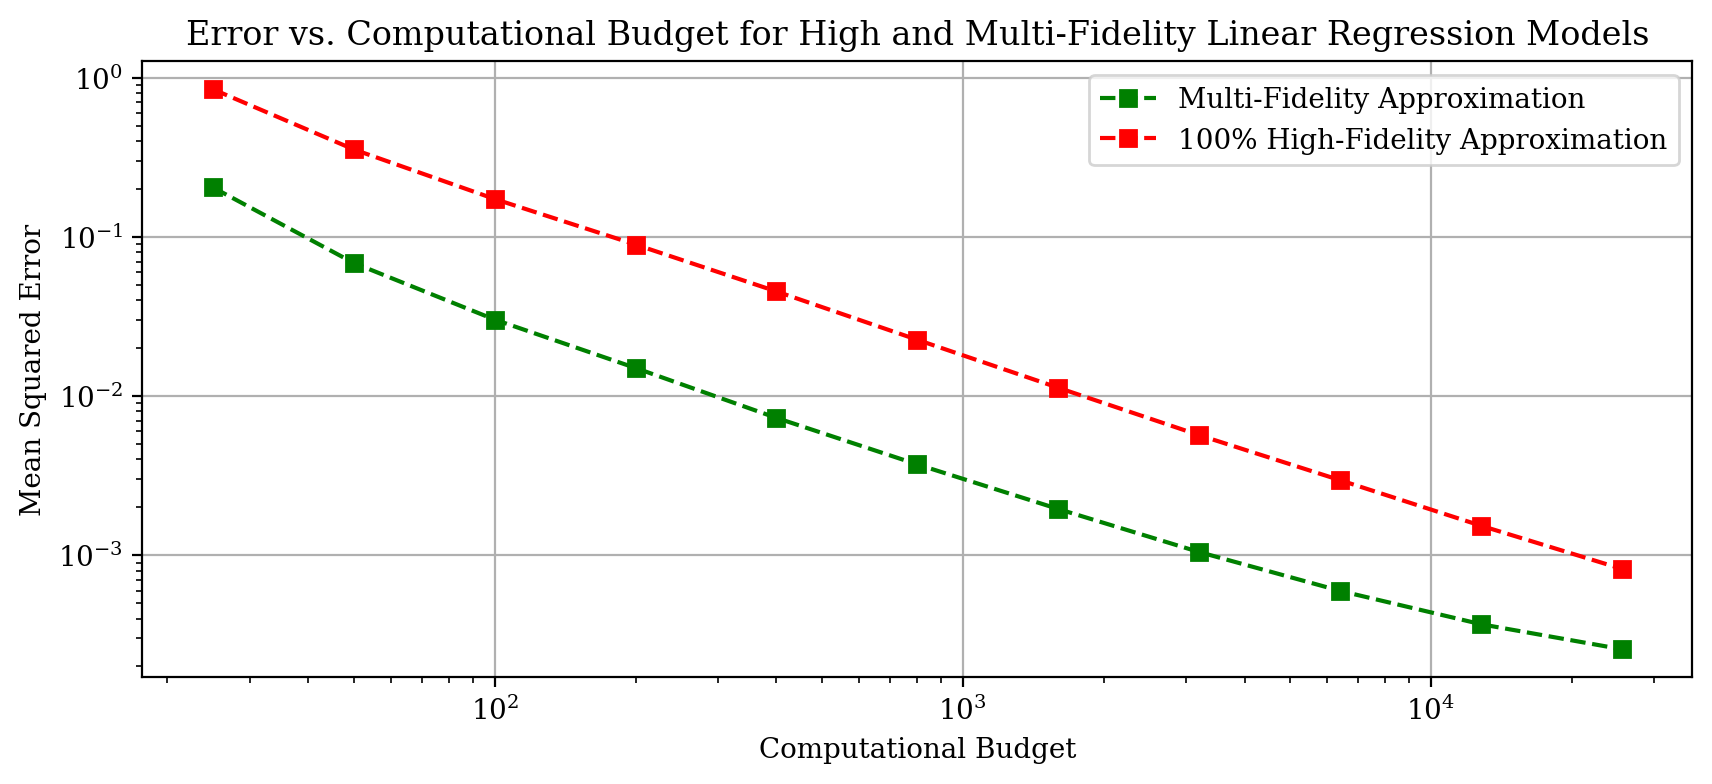

In [74]:
mf_means, mf_two_sigmas = np.array(mf_means), np.array(mf_two_sigmas)
hf_means, hf_two_sigmas = np.array(hf_means), np.array(hf_two_sigmas)

plt.figure(figsize=(10,4), dpi=200)
plt.loglog(Bs, mf_means, color = 'green', label = "Multi-Fidelity Approximation", marker = 's', linestyle = 'dashed')
# plt.fill_between(Bs, mf_means - mf_two_sigmas/2, mf_means + mf_two_sigmas/2, color = 'green', alpha = 0.3)

plt.loglog(Bs, hf_means, color = 'red', label = "100% High-Fidelity Approximation", marker = 's', linestyle = 'dashed')
# plt.fill_between(Bs, hf_means - hf_two_sigmas/2, hf_means + hf_two_sigmas/2, color = 'red', alpha = 0.3)

plt.xlabel("Computational Budget")
plt.ylabel("Mean Squared Error")
plt.title("Error vs. Computational Budget for High and Multi-Fidelity Linear Regression Models")
# plt.ylim(0, 25)
plt.legend()
plt.grid()

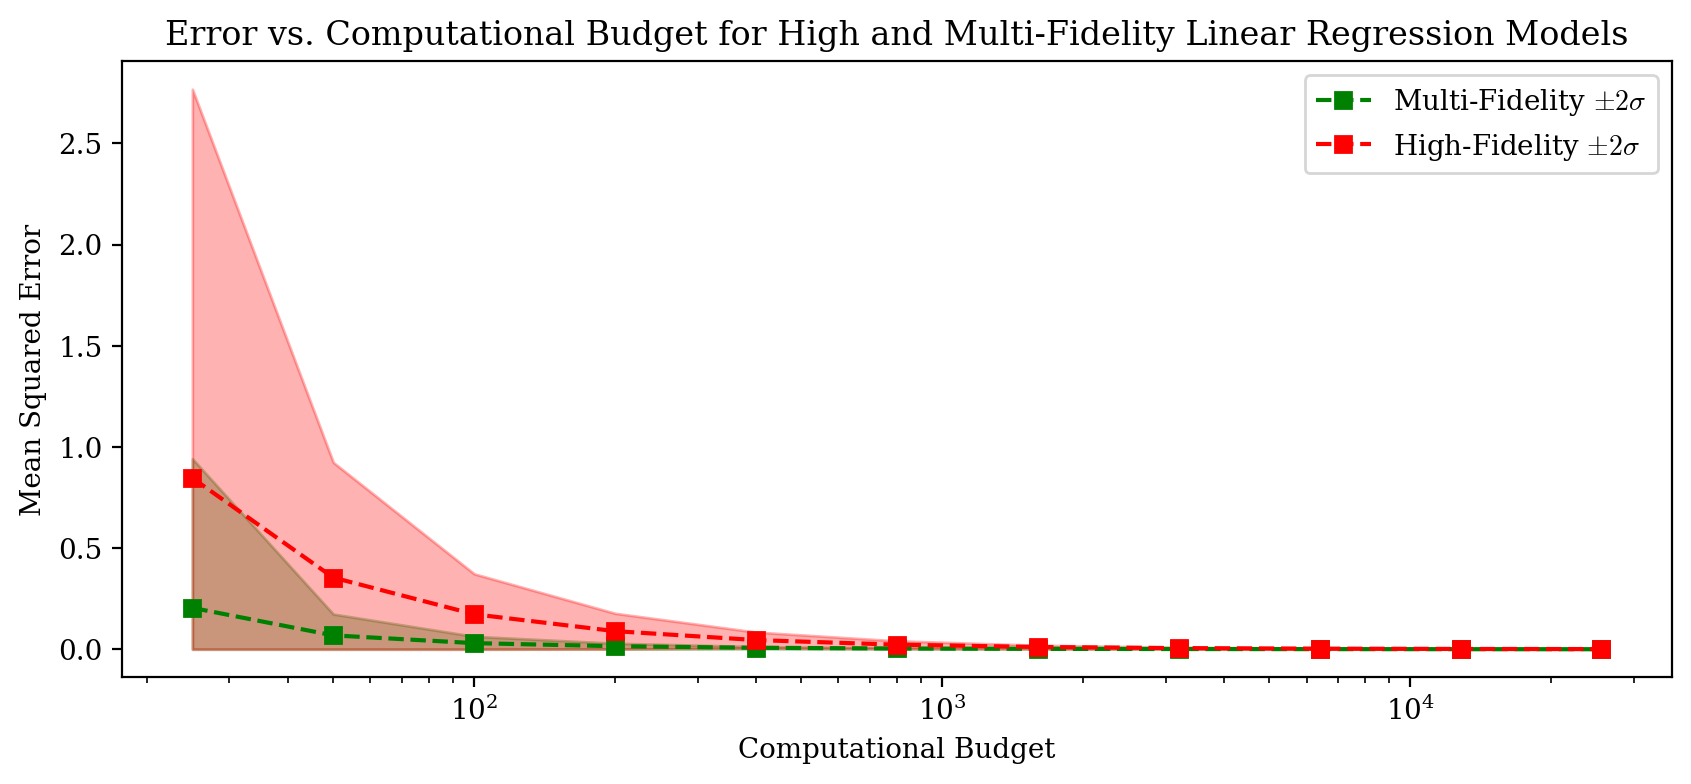

In [78]:
plt.figure(figsize=(10,4), dpi=200)
plt.semilogx(Bs, mf_means, color = 'green', label = "Multi-Fidelity $\\pm 2 \\sigma$", marker = 's', linestyle = 'dashed')
plt.fill_between(Bs, np.maximum(0, mf_means - mf_two_sigmas), mf_means + mf_two_sigmas, color = 'green', alpha = 0.3)

plt.semilogx(Bs, hf_means, color = 'red', label = "High-Fidelity $\\pm 2 \\sigma$", marker = 's', linestyle = 'dashed')
plt.fill_between(Bs, np.maximum(0, hf_means - hf_two_sigmas), hf_means + hf_two_sigmas, color = 'red', alpha = 0.3)

plt.xlabel("Computational Budget")
plt.ylabel("Mean Squared Error")
plt.title("Error vs. Computational Budget for High and Multi-Fidelity Linear Regression Models")
# plt.ylim(-1, 15)
# plt.xlim(50, Bs[-1])
plt.legend()

(0.0, 22.5)

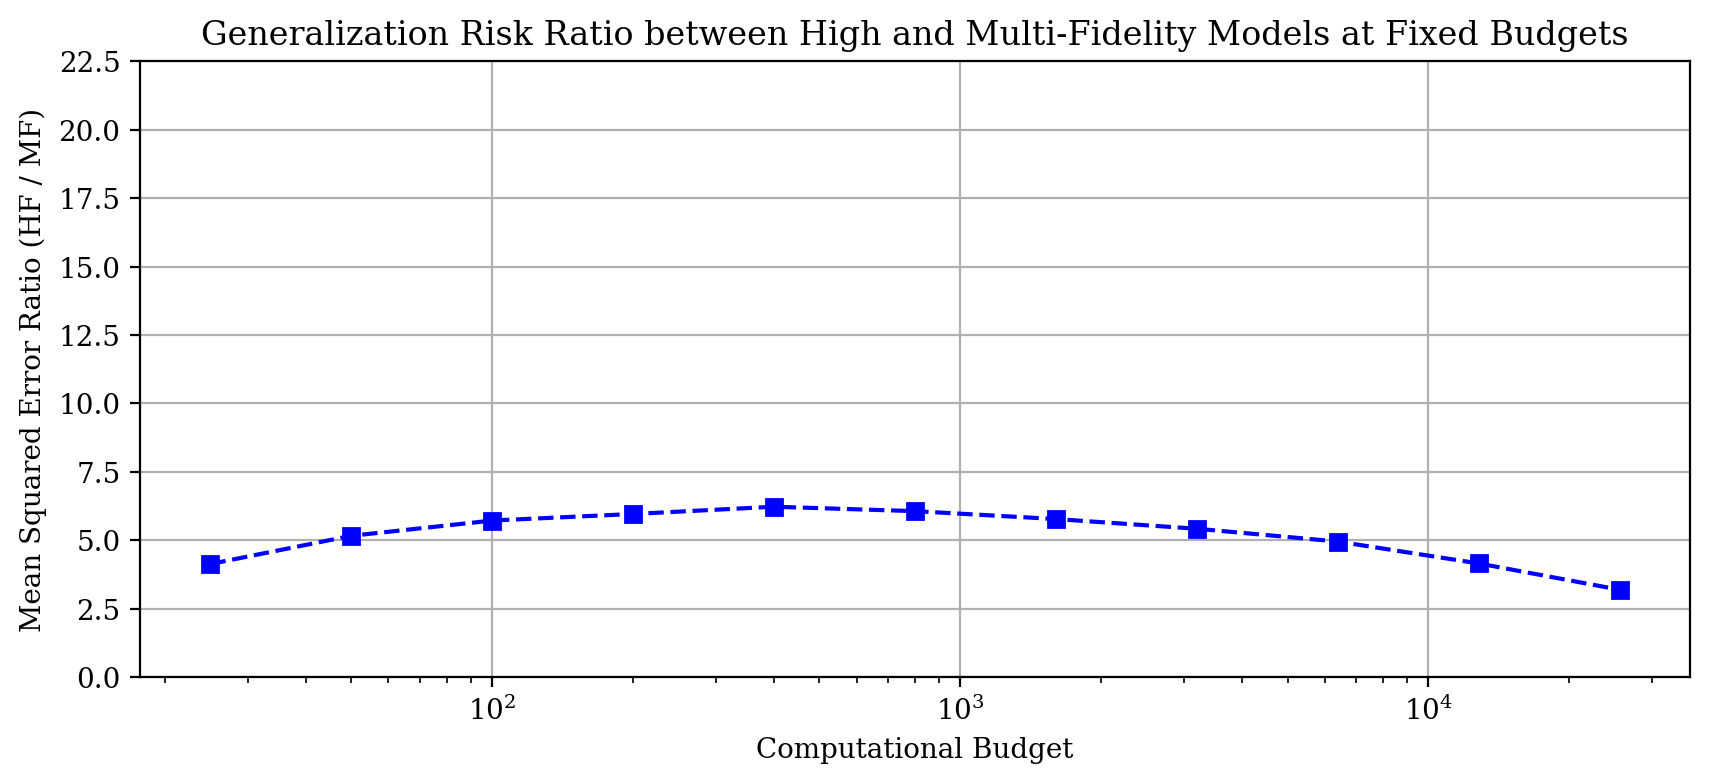

In [76]:
plt.figure(figsize=(10,4), dpi=200)
plt.semilogx(Bs, hf_means / mf_means, marker = 's', linestyle = 'dashed', color = 'blue')
plt.xlabel("Computational Budget")
plt.ylabel("Mean Squared Error Ratio (HF / MF)")
plt.title("Generalization Risk Ratio between High and Multi-Fidelity Models at Fixed Budgets")
plt.grid()
plt.ylim(0,22.5)